# Phase 1: Basic Concepts - RL Fundamentals

## Implementing Core RL Components

**Time Estimate:** 45 minutes  
**Prerequisites:** Completed Phase 0  
**Goal:** Understand RL by implementing it

---

## What We'll Build

In this phase, you'll implement:
1. A simple MDP (Markov Decision Process)
2. Reward functions
3. Basic policy representation
4. Simple optimization

All with concrete, runnable code!

## Section 1: Setting Up

Let's start with imports and setup.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Callable
from dataclasses import dataclass
from collections import defaultdict

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Imports successful!")

✅ Imports successful!


## Section 2: Representing Problems

Let's define what a reasoning problem looks like.

In [3]:
@dataclass
class ReasoningProblem:
    """Represents a reasoning problem."""
    problem_id: int
    question: str
    ground_truth: str  # The correct answer
    category: str  # Type of problem (math, logic, etc.)

@dataclass
class ReasoningAttempt:
    """Represents one attempt at solving a problem."""
    problem_id: int
    reasoning_chain: List[str]  # Steps taken
    final_answer: str  # The conclusion
    correctness: int  # 1 if correct, 0 if incorrect
    reasoning_length: int  # How many steps

# Create some example problems
example_problems = [
    ReasoningProblem(
        problem_id=1,
        question="What is 7 × 8?",
        ground_truth="56",
        category="arithmetic"
    ),
    ReasoningProblem(
        problem_id=2,
        question="If Sarah has 12 apples and gives half to Tom, then Tom gives a third to Lisa, how many does Lisa have?",
        ground_truth="2",
        category="word_problem"
    ),
    ReasoningProblem(
        problem_id=3,
        question="What is the capital of France?",
        ground_truth="Paris",
        category="knowledge"
    ),
]

print("✅ Problem structures defined!")
print(f"\nExample problem:\n{example_problems[0]}")

✅ Problem structures defined!

Example problem:
ReasoningProblem(problem_id=1, question='What is 7 × 8?', ground_truth='56', category='arithmetic')


## Section 3: Reward Functions

The reward function is the heart of RL - it tells the model what success looks like.

In [4]:
class RewardFunction:
    """Base class for reward functions."""
    
    def __call__(self, attempt: ReasoningAttempt) -> float:
        """Calculate reward for an attempt."""
        raise NotImplementedError

class SimpleCorrectnessReward(RewardFunction):
    """Simplest reward: correct answer = 1, wrong = 0."""
    
    def __call__(self, attempt: ReasoningAttempt) -> float:
        return float(attempt.correctness)

class ReasoningLengthReward(RewardFunction):
    """Reward correctness AND showing work."""
    
    def __init__(self, reasoning_bonus: float = 0.2):
        self.reasoning_bonus = reasoning_bonus
    
    def __call__(self, attempt: ReasoningAttempt) -> float:
        # Base reward for correctness
        base_reward = float(attempt.correctness)
        
        # Bonus for showing reasoning (only if correct)
        if attempt.correctness == 1:
            # Reward more work, but with diminishing returns
            reasoning_bonus = min(
                attempt.reasoning_length / 10,  # Scale by 10 steps
                self.reasoning_bonus
            )
            return base_reward + reasoning_bonus
        
        return base_reward

class ScaledReward(RewardFunction):
    """More nuanced: penalize wrong answers, reward correct ones."""
    
    def __call__(self, attempt: ReasoningAttempt) -> float:
        if attempt.correctness == 1:
            return 1.0
        else:
            # Penalize wrong answers
            return -0.5

# Test the reward functions
attempt_correct = ReasoningAttempt(
    problem_id=1,
    reasoning_chain=["7 × 8 = 56"],
    final_answer="56",
    correctness=1,
    reasoning_length=1
)

attempt_correct_verbose = ReasoningAttempt(
    problem_id=1,
    reasoning_chain=["Let me calculate", "7 × 8", "= 7 × (5+3)", "= 35 + 21", "= 56"],
    final_answer="56",
    correctness=1,
    reasoning_length=5
)

attempt_wrong = ReasoningAttempt(
    problem_id=1,
    reasoning_chain=["I think it's 54"],
    final_answer="54",
    correctness=0,
    reasoning_length=1
)

# Compare rewards
simple_reward = SimpleCorrectnessReward()
reasoning_reward = ReasoningLengthReward()
scaled_reward = ScaledReward()

print("Reward Function Comparison\n" + "="*50)
print(f"\nCorrect (short): {attempt_correct.final_answer}")
print(f"  Simple:    {simple_reward(attempt_correct):.2f}")
print(f"  Reasoning: {reasoning_reward(attempt_correct):.2f}")
print(f"  Scaled:    {scaled_reward(attempt_correct):.2f}")

print(f"\nCorrect (verbose): {attempt_correct_verbose.final_answer}")
print(f"  Simple:    {simple_reward(attempt_correct_verbose):.2f}")
print(f"  Reasoning: {reasoning_reward(attempt_correct_verbose):.2f}")
print(f"  Scaled:    {scaled_reward(attempt_correct_verbose):.2f}")

print(f"\nWrong: {attempt_wrong.final_answer}")
print(f"  Simple:    {simple_reward(attempt_wrong):.2f}")
print(f"  Reasoning: {reasoning_reward(attempt_wrong):.2f}")
print(f"  Scaled:    {scaled_reward(attempt_wrong):.2f}")

Reward Function Comparison

Correct (short): 56
  Simple:    1.00
  Reasoning: 1.10
  Scaled:    1.00

Correct (verbose): 56
  Simple:    1.00
  Reasoning: 1.20
  Scaled:    1.00

Wrong: 54
  Simple:    0.00
  Reasoning: 0.00
  Scaled:    -0.50


## Section 4: Simulating Model Behavior

Let's simulate what different models might produce.

In [5]:
class SimpleReasoningModel:
    """Simulates a reasoning model with different strategies."""
    
    def __init__(self, accuracy: float = 0.7, verbosity: float = 0.5):
        """Initialize model.
        
        Args:
            accuracy: Probability of getting right answer (0-1)
            verbosity: How much reasoning to show (0-1)
        """
        self.accuracy = accuracy
        self.verbosity = verbosity
    
    def attempt_problem(self, problem: ReasoningProblem) -> ReasoningAttempt:
        """Attempt to solve a problem."""
        # Decide if we'll be correct
        is_correct = np.random.random() < self.accuracy
        
        # Determine reasoning length based on verbosity
        base_length = int(np.random.normal(loc=5, scale=2))
        reasoning_length = max(1, int(base_length * self.verbosity))
        
        # Generate reasoning chain
        reasoning_chain = [f"Step {i+1}" for i in range(reasoning_length)]
        
        # Generate answer
        if is_correct:
            final_answer = problem.ground_truth
            correctness = 1
        else:
            # Generate wrong answer
            final_answer = f"Wrong_{np.random.randint(100)}"
            correctness = 0
        
        return ReasoningAttempt(
            problem_id=problem.problem_id,
            reasoning_chain=reasoning_chain,
            final_answer=final_answer,
            correctness=correctness,
            reasoning_length=reasoning_length
        )

# Create models with different strategies
quick_model = SimpleReasoningModel(accuracy=0.6, verbosity=0.2)  # Quick but not very accurate
thorough_model = SimpleReasoningModel(accuracy=0.8, verbosity=0.8)  # Thorough and accurate
lazy_model = SimpleReasoningModel(accuracy=0.7, verbosity=0.1)  # Lazy but decent

# Test on a problem
test_problem = example_problems[0]  # "What is 7 × 8?"

print("Model Comparison on: 'What is 7 × 8?'\n" + "="*50)

for name, model in [("Quick Model", quick_model), 
                     ("Thorough Model", thorough_model),
                     ("Lazy Model", lazy_model)]:
    attempt = model.attempt_problem(test_problem)
    reward = SimpleCorrectnessReward()(attempt)
    print(f"\n{name}:")
    print(f"  Answer: {attempt.final_answer} (Correct: {attempt.correctness})")
    print(f"  Reasoning steps: {attempt.reasoning_length}")
    print(f"  Reward: {reward:.2f}")

Model Comparison on: 'What is 7 × 8?'

Quick Model:
  Answer: 56 (Correct: 1)
  Reasoning steps: 1
  Reward: 1.00

Thorough Model:
  Answer: 56 (Correct: 1)
  Reasoning steps: 4
  Reward: 1.00

Lazy Model:
  Answer: 56 (Correct: 1)
  Reasoning steps: 1
  Reward: 1.00


## Section 5: Group Relative Policy Optimization (GRPO)

Now let's implement the core GRPO concept: comparing attempts relative to each other.

In [6]:
class GRPO:
    """Group Relative Policy Optimization.
    
    Core idea: Compare model outputs relative to each other
    rather than against a fixed baseline.
    """
    
    def __init__(self, reward_fn: RewardFunction):
        self.reward_fn = reward_fn
    
    def compute_relative_rewards(
        self, 
        attempts: List[ReasoningAttempt]
    ) -> List[float]:
        """Compute rewards relative to group mean.
        
        Formula: relative_reward = reward - mean(all_rewards)
        """
        # Calculate absolute rewards
        absolute_rewards = [self.reward_fn(attempt) for attempt in attempts]
        
        # Calculate group mean
        mean_reward = np.mean(absolute_rewards)
        
        # Calculate relative rewards
        relative_rewards = [r - mean_reward for r in absolute_rewards]
        
        return relative_rewards, absolute_rewards, mean_reward
    
    def analyze_group(self, attempts: List[ReasoningAttempt]) -> Dict:
        """Analyze a group of attempts."""
        relative_rewards, absolute_rewards, mean_reward = self.compute_relative_rewards(attempts)
        
        return {
            'absolute_rewards': absolute_rewards,
            'relative_rewards': relative_rewards,
            'mean_reward': mean_reward,
            'max_reward': max(absolute_rewards),
            'min_reward': min(absolute_rewards),
            'num_attempts': len(attempts)
        }

# Create multiple attempts
attempts = [
    ReasoningAttempt(
        problem_id=1,
        reasoning_chain=["7 × 8 = 56"],
        final_answer="56",
        correctness=1,
        reasoning_length=1
    ),
    ReasoningAttempt(
        problem_id=1,
        reasoning_chain=["Let me think", "7 × 8", "= 7 × 8", "= 56"],
        final_answer="56",
        correctness=1,
        reasoning_length=4
    ),
    ReasoningAttempt(
        problem_id=1,
        reasoning_chain=["I think it's 54"],
        final_answer="54",
        correctness=0,
        reasoning_length=1
    ),
    ReasoningAttempt(
        problem_id=1,
        reasoning_chain=["7 × 8 = 56"],
        final_answer="56",
        correctness=1,
        reasoning_length=1
    ),
]

# Analyze with GRPO
grpo = GRPO(SimpleCorrectnessReward())
analysis = grpo.analyze_group(attempts)

print("GRPO Analysis: Multiple Attempts at '7 × 8 = ?'\n" + "="*60)
print(f"\nTotal attempts: {analysis['num_attempts']}")
print(f"Mean reward: {analysis['mean_reward']:.2f}")
print(f"Reward range: [{analysis['min_reward']:.2f}, {analysis['max_reward']:.2f}]")
print("\nDetailed Analysis:")
print("-" * 60)

for i, (attempt, abs_reward, rel_reward) in enumerate(zip(
    attempts, 
    analysis['absolute_rewards'],
    analysis['relative_rewards']
)):
    print(f"\nAttempt {i+1}:")
    print(f"  Answer: {attempt.final_answer} (Correct: {'✓' if attempt.correctness else '✗'})")
    print(f"  Reasoning steps: {attempt.reasoning_length}")
    print(f"  Absolute reward: {abs_reward:+.2f}")
    print(f"  Relative reward: {rel_reward:+.2f} {'(ABOVE average)' if rel_reward > 0 else '(BELOW average)'}")

GRPO Analysis: Multiple Attempts at '7 × 8 = ?'

Total attempts: 4
Mean reward: 0.75
Reward range: [0.00, 1.00]

Detailed Analysis:
------------------------------------------------------------

Attempt 1:
  Answer: 56 (Correct: ✓)
  Reasoning steps: 1
  Absolute reward: +1.00
  Relative reward: +0.25 (ABOVE average)

Attempt 2:
  Answer: 56 (Correct: ✓)
  Reasoning steps: 4
  Absolute reward: +1.00
  Relative reward: +0.25 (ABOVE average)

Attempt 3:
  Answer: 54 (Correct: ✗)
  Reasoning steps: 1
  Absolute reward: +0.00
  Relative reward: -0.75 (BELOW average)

Attempt 4:
  Answer: 56 (Correct: ✓)
  Reasoning steps: 1
  Absolute reward: +1.00
  Relative reward: +0.25 (ABOVE average)


## Section 6: Learning Signal Analysis

Let's see how the model would learn from these signals.

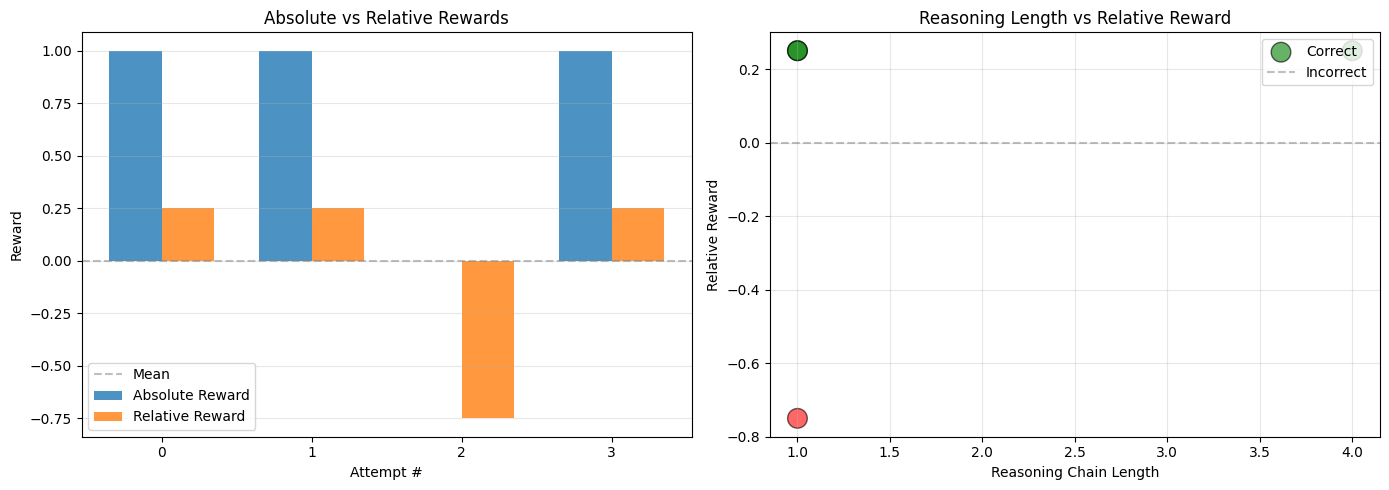

✅ Learning signal visualization saved!


In [7]:
def visualize_learning_signal(attempts, analysis):
    """Visualize the learning signals."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Absolute vs Relative Rewards
    x = np.arange(len(attempts))
    width = 0.35
    
    axes[0].bar(x - width/2, analysis['absolute_rewards'], width, label='Absolute Reward', alpha=0.8)
    axes[0].bar(x + width/2, analysis['relative_rewards'], width, label='Relative Reward', alpha=0.8)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Mean')
    axes[0].set_xlabel('Attempt #')
    axes[0].set_ylabel('Reward')
    axes[0].set_title('Absolute vs Relative Rewards')
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Plot 2: Reasoning Length vs Correctness
    colors = ['green' if a.correctness else 'red' for a in attempts]
    reasoning_lengths = [a.reasoning_length for a in attempts]
    rewards = analysis['relative_rewards']
    
    axes[1].scatter(reasoning_lengths, rewards, s=200, c=colors, alpha=0.6, edgecolors='black')
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Reasoning Chain Length')
    axes[1].set_ylabel('Relative Reward')
    axes[1].set_title('Reasoning Length vs Relative Reward')
    axes[1].grid(alpha=0.3)
    axes[1].legend(['Correct', 'Incorrect'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig('phase1_learning_signal.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("✅ Learning signal visualization saved!")

visualize_learning_signal(attempts, analysis)

## Section 7: Training Simulation

Let's simulate what happens when a model learns from RL.

In [8]:
class SimpleReasoningLearner:
    """Simulates learning through RL."""
    
    def __init__(self, initial_accuracy=0.5, initial_verbosity=0.3):
        self.accuracy = initial_accuracy
        self.verbosity = initial_verbosity
        self.history = {
            'accuracy': [self.accuracy],
            'verbosity': [self.verbosity],
            'avg_reward': []
        }
    
    def train_step(
        self, 
        problems: List[ReasoningProblem],
        reward_fn: RewardFunction,
        num_attempts_per_problem: int = 4,
        learning_rate: float = 0.05
    ):
        """One training step: collect attempts and learn."""
        model = SimpleReasoningModel(self.accuracy, self.verbosity)
        
        total_relative_reward = 0
        num_problem_groups = 0
        
        for problem in problems:
            # Collect attempts
            attempts = [
                model.attempt_problem(problem)
                for _ in range(num_attempts_per_problem)
            ]
            
            # Analyze with GRPO
            grpo = GRPO(reward_fn)
            rel_rewards, _, mean_reward = grpo.compute_relative_rewards(attempts)
            total_relative_reward += mean_reward
            num_problem_groups += 1
            
            # Simple learning: move toward better strategy
            # If mean reward is positive, increase accuracy
            if mean_reward > 0:
                self.accuracy = min(1.0, self.accuracy + learning_rate * 0.1)
                self.verbosity = min(1.0, self.verbosity + learning_rate * 0.05)
            elif mean_reward < 0:
                self.accuracy = max(0.0, self.accuracy - learning_rate * 0.05)
        
        avg_reward = total_relative_reward / num_problem_groups
        self.history['accuracy'].append(self.accuracy)
        self.history['verbosity'].append(self.verbosity)
        self.history['avg_reward'].append(avg_reward)
        
        return avg_reward

# Train a model
learner = SimpleReasoningLearner(initial_accuracy=0.5, initial_verbosity=0.2)
print("Training model with RL...\n")

for epoch in range(10):
    reward = learner.train_step(
        example_problems,
        SimpleCorrectnessReward(),
        num_attempts_per_problem=4,
        learning_rate=0.05
    )
    print(f"Epoch {epoch+1:2d}: Accuracy={learner.accuracy:.3f}, "
          f"Verbosity={learner.verbosity:.3f}, Reward={reward:+.3f}")

print(f"\n✅ Training complete!")
print(f"Final accuracy: {learner.accuracy:.3f} (started at 0.500)")
print(f"Final verbosity: {learner.verbosity:.3f} (started at 0.200)")

Training model with RL...

Epoch  1: Accuracy=0.510, Verbosity=0.205, Reward=+0.417
Epoch  2: Accuracy=0.525, Verbosity=0.213, Reward=+0.583
Epoch  3: Accuracy=0.535, Verbosity=0.218, Reward=+0.333
Epoch  4: Accuracy=0.550, Verbosity=0.225, Reward=+0.667
Epoch  5: Accuracy=0.565, Verbosity=0.233, Reward=+0.583
Epoch  6: Accuracy=0.580, Verbosity=0.240, Reward=+0.417
Epoch  7: Accuracy=0.590, Verbosity=0.245, Reward=+0.500
Epoch  8: Accuracy=0.605, Verbosity=0.253, Reward=+0.667
Epoch  9: Accuracy=0.620, Verbosity=0.260, Reward=+0.417
Epoch 10: Accuracy=0.635, Verbosity=0.268, Reward=+0.750

✅ Training complete!
Final accuracy: 0.635 (started at 0.500)
Final verbosity: 0.268 (started at 0.200)


## Section 8: Visualizing Learning Progress

Let's see how the model improved.

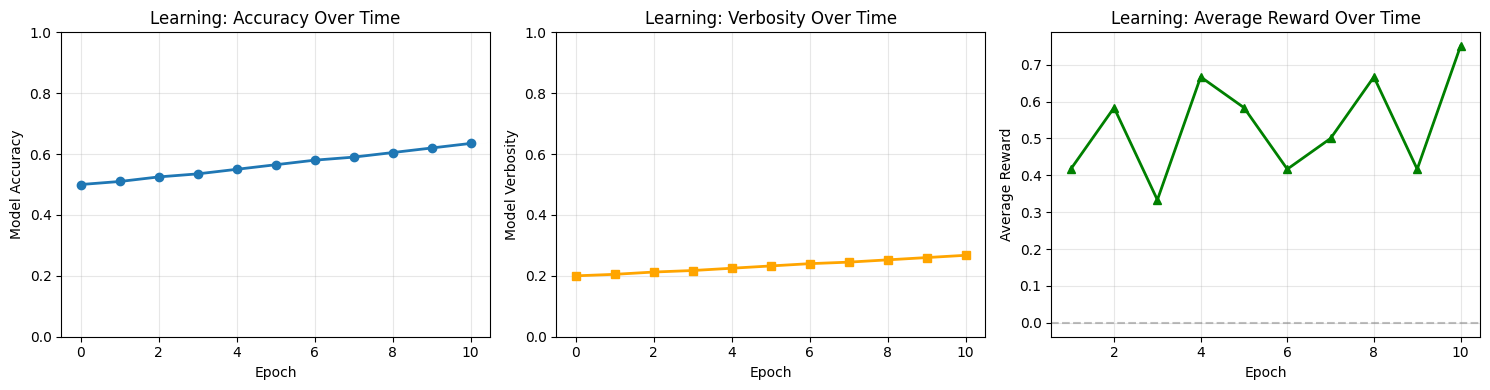

✅ Learning progress visualization saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(len(learner.history['accuracy']))

# Plot 1: Accuracy over time
axes[0].plot(epochs, learner.history['accuracy'], marker='o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Model Accuracy')
axes[0].set_title('Learning: Accuracy Over Time')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: Verbosity over time
axes[1].plot(epochs, learner.history['verbosity'], marker='s', linewidth=2, markersize=6, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Model Verbosity')
axes[1].set_title('Learning: Verbosity Over Time')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

# Plot 3: Reward over time
axes[2].plot(epochs[1:], learner.history['avg_reward'], marker='^', linewidth=2, markersize=6, color='green')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Average Reward')
axes[2].set_title('Learning: Average Reward Over Time')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_learning_progress.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Learning progress visualization saved!")

## Section 9: Key Insights

What we've learned by implementing RL:

In [ ]:
insights = """
KEY INSIGHTS FROM PHASE 1:
==========================

1. REWARD FUNCTIONS MATTER
   - Different reward functions lead to different behaviors
   - Simple correctness: Focus on getting right answer
   - With reasoning bonus: Encourage step-by-step thinking
   - Scaled rewards: Penalize wrong answers, boost correct ones

2. RELATIVE REWARDS ARE KEY
   - Comparing to group mean creates clear learning signal
   - Tells model: "You're better/worse than your typical output"
   - More stable than comparing to fixed baseline

3. MODELS LEARN TO IMPROVE
   - Positive reward signal → model improves accuracy
   - Model also learns to show more reasoning
   - Learning is gradual but consistent

4. TRADE-OFFS EXIST
   - Accuracy vs Speed (reasoning length)
   - Can be controlled through reward design
   - Different domains need different rewards

NEXT STEPS:
===========
Phase 2 will implement the actual GRPO algorithm
with neural networks and gradient-based optimization.

This foundation of understanding is crucial!
"""

print(insights)

## Summary

✅ **Reward Functions** - Define what success looks like  
✅ **Group Relative Policy Optimization** - Core RL idea  
✅ **Learning Signal** - How models improve  
✅ **Training Simulation** - Seeing improvement in action  
✅ **Custom Rewards** - Designing for your domain  

Ready? → Open `phase2_algorithms.ipynb`